# notebook 19 - final results

Pulls every result together into the tables and figures that go in the dissertation, so I am not copying numbers out of a dozen notebooks by hand and getting one wrong.

Everything here is read from the saved csv files in processed/, nothing is retrained.

Outputs go to processed/final_* and plots/final_*.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = r'D:\Final year project'
PROC = os.path.join(ROOT,'processed')
PLOTS = os.path.join(ROOT,'plots')

def load(name):
    p = os.path.join(PROC, name)
    return pd.read_csv(p) if os.path.exists(p) else None

for f in ['search_summary.csv','baseline_results.csv','rq2_summary.csv',
          'rq2_per_city_vs_pooled.csv','conformal_tft_per_horizon_calibrated.csv',
          'tft_v2_final_per_city.csv','sydney_alignment_results.csv',
          'rq3_permutation_importance.csv','rq3_tft_encoder_importance.csv']:
    print(f'{f:<45} {"found" if load(f) is not None else "MISSING"}')

search_summary.csv                            found
baseline_results.csv                          found
rq2_summary.csv                               found
rq2_per_city_vs_pooled.csv                    found
conformal_tft_per_horizon_calibrated.csv      found
tft_v2_final_per_city.csv                     found
sydney_alignment_results.csv                  found
rq3_permutation_importance.csv                found
rq3_tft_encoder_importance.csv                found


## table 1 - model comparison

The headline table. Everything tuned, same test set, same horizon.

In [2]:
search = load('search_summary.csv')
base = load('baseline_results.csv')

tuned = {r['model']: r['test_MAE'] for _, r in search.iterrows()}
rows = [
    ('TFT',               tuned.get('TFT'),               'tuned', 'learning rate search'),
    ('Gradient boosting', tuned.get('Gradient boosting'), 'tuned', '12 configs'),
    ('LSTM',              tuned.get('LSTM'),              'tuned', '8 configs'),
]
bl = {r['model']: r['MAE'] for _, r in base.iterrows()}
for nm in ['Linear regression','Seasonal naive','Climatology','Persistence']:
    rows.append((nm, bl.get(nm), 'baseline', '-'))

t1 = pd.DataFrame(rows, columns=['Model','Test MAE (C)','Type','Search'])
t1['Test MAE (C)'] = t1['Test MAE (C)'].astype(float).round(3)
t1 = t1.sort_values('Test MAE (C)').reset_index(drop=True)
print(t1.to_string(index=False))
t1.to_csv(os.path.join(PROC,'final_table1_models.csv'), index=False)

            Model  Test MAE (C)     Type               Search
              TFT         1.247    tuned learning rate search
Gradient boosting         1.263    tuned           12 configs
             LSTM         1.266    tuned            8 configs
Linear regression         1.575 baseline                    -
   Seasonal naive         2.091 baseline                    -
      Climatology         2.470 baseline                    -
      Persistence         2.935 baseline                    -


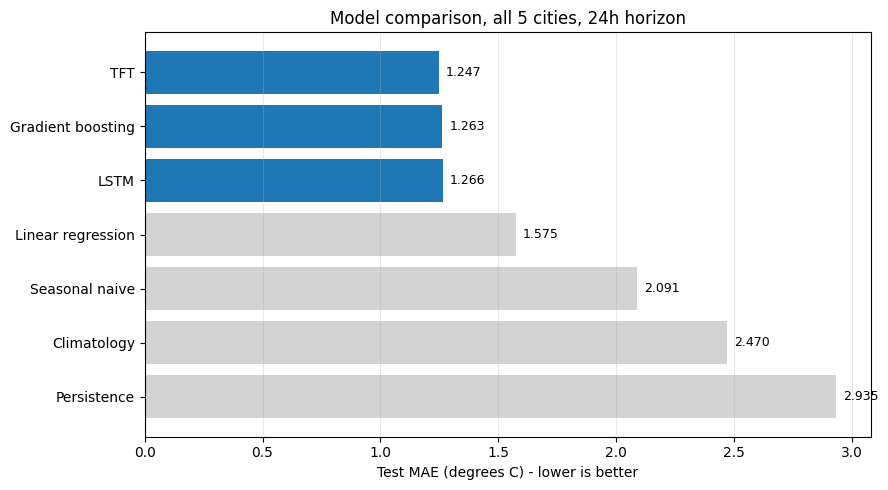

In [3]:
cols = ['tab:blue' if t=='tuned' else 'lightgrey' for t in t1['Type']]
plt.figure(figsize=(9,5))
plt.barh(t1['Model'][::-1], t1['Test MAE (C)'][::-1], color=cols[::-1])
for i,v in enumerate(t1['Test MAE (C)'][::-1]):
    plt.text(v+0.03, i, f'{v:.3f}', va='center', fontsize=9)
plt.xlabel('Test MAE (degrees C) - lower is better')
plt.title('Model comparison, all 5 cities, 24h horizon')
plt.grid(axis='x', alpha=.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS,'final_model_comparison.png'), dpi=150)
plt.show()

## table 2 - the effect of tuning

This is the one that answers the fairness question - what each model scored before and after its own search.

In [4]:
# gbm untuned is 1.286, not the 1.258 from the baselines notebook. that one sampled the
# training windows at a denser stride so the untuned model had seen more data than the
# tuned one, which made tuning look like it made gbm worse. 1.286 is the matched re-run.
untuned = {'TFT': 1.53, 'Gradient boosting': 1.286, 'LSTM': 1.39}
t2 = pd.DataFrame([{
    'Model': m,
    'Untuned MAE': untuned[m],
    'Tuned MAE': round(float(tuned[m]),3),
    'Change %': round(100*(float(tuned[m])-untuned[m])/untuned[m],1)
} for m in ['TFT','Gradient boosting','LSTM']])
print(t2.to_string(index=False))
t2.to_csv(os.path.join(PROC,'final_table2_tuning.csv'), index=False)

            Model  Untuned MAE  Tuned MAE  Change %
              TFT        1.530      1.247     -18.5
Gradient boosting        1.286      1.263      -1.8
             LSTM        1.390      1.266      -8.9


## table 3 - RQ2, multi-city vs single-city

experiment  pooled_overall_mae  per_city_mean_mae winner
       RQ2              1.2677              1.272 pooled

    city  pooled_mae  per_city_mae  difference
    Jena      1.3139        1.3558      0.0419
  London      1.2255        1.2309      0.0054
New_York      1.5381        1.5595      0.0214
  Sydney      1.1716        1.1583     -0.0133
   Tokyo      1.1131        1.1357      0.0226
    MEAN      1.2724        1.2880      0.0156


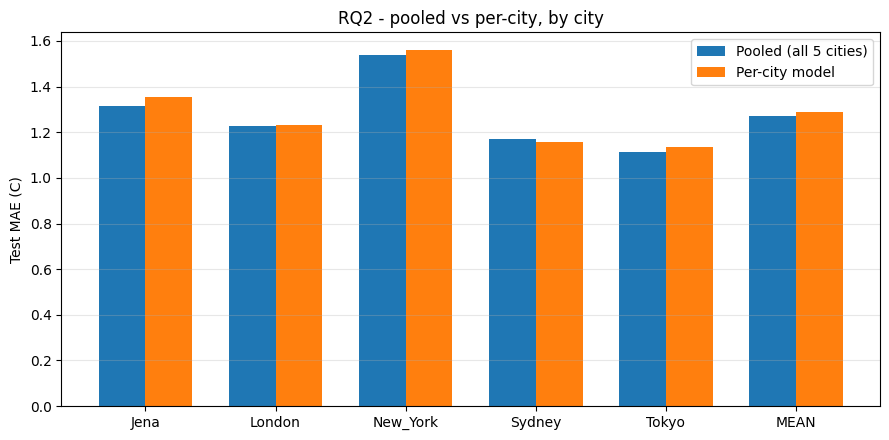

In [5]:
rq2 = load('rq2_summary.csv')
pc = load('rq2_per_city_vs_pooled.csv')
print(rq2.to_string(index=False))
print()
if pc is not None:
    print(pc.to_string(index=False))
    pc.to_csv(os.path.join(PROC,'final_table3_rq2.csv'), index=False)
    x = np.arange(len(pc)); w=0.36
    plt.figure(figsize=(9,4.5))
    plt.bar(x-w/2, pc['pooled_mae'], w, label='Pooled (all 5 cities)', color='tab:blue')
    plt.bar(x+w/2, pc['per_city_mae'], w, label='Per-city model', color='tab:orange')
    plt.xticks(x, pc['city']); plt.ylabel('Test MAE (C)')
    plt.title('RQ2 - pooled vs per-city, by city')
    plt.legend(); plt.grid(axis='y', alpha=.3)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS,'final_rq2_per_city.png'), dpi=150)
    plt.show()

## table 4 - RQ4, interval calibration

In [6]:
cf = load('conformal_tft_per_horizon_calibrated.csv')
if cf is not None:
    sel = cf[cf['horizon'].isin([1,6,12,18,24])][['horizon','q_hat','coverage_pct','avg_width']]
    sel.columns = ['Horizon (h)','Half-width (C)','Coverage %','Full width (C)']
    print(sel.round(2).to_string(index=False))
    sel.round(2).to_csv(os.path.join(PROC,'final_table4_conformal.csv'), index=False)
    print()
    print('coverage range across all 24 horizons: %.1f%% to %.1f%%' % (cf['coverage_pct'].min(), cf['coverage_pct'].max()))

 Horizon (h)  Half-width (C)  Coverage %  Full width (C)
           1            1.26       90.28            2.52
           6            2.66       92.74            5.32
          12            3.65       92.79            7.30
          18            4.32       93.06            8.64
          24            4.81       93.36            9.62

coverage range across all 24 horizons: 90.3% to 93.4%


## table 5 - RQ3, what drives the forecast

In [7]:
enc = load('rq3_tft_encoder_importance.csv')
perm = load('rq3_permutation_importance.csv')
if enc is not None:
    enc.columns = ['variable','pct_weight']
    print('TFT encoder - top 10'); print(enc.head(10).round(2).to_string(index=False))
    enc.head(10).round(2).to_csv(os.path.join(PROC,'final_table5a_tft_importance.csv'), index=False)
print()
if perm is not None:
    print('Permutation importance - top 10'); print(perm.head(10).to_string(index=False))
    perm.head(10).to_csv(os.path.join(PROC,'final_table5b_permutation.csv'), index=False)

TFT encoder - top 10
        variable  pct_weight
    water_vapour       22.87
     temperature       16.95
  wind_direction        5.17
      wind_speed        4.29
        hour_sin        4.10
    pressure_msl        3.98
          wind_v        3.39
surface_pressure        3.38
          wind_u        3.12
soil_temperature        3.08

Permutation importance - top 10
         feature  mae_increase
   temp_roll_24h        1.2747
     temperature        1.2471
   wet_bulb_temp        0.6751
        hour_sin        0.6455
     temp_lag_6h        0.5298
    temp_roll_6h        0.4447
   dayofyear_cos        0.3793
        hour_cos        0.3631
    water_vapour        0.3065
soil_temperature        0.2950


## research question summary

In [8]:
best = t1.iloc[0]
spread = t1[t1['Type']=='tuned']['Test MAE (C)']
summary = pd.DataFrame([
  {'RQ':'RQ1','Question':'Can a TFT outperform an LSTM?',
   'Answer':f"Yes but narrowly - TFT {tuned['TFT']:.3f} vs LSTM {tuned['LSTM']:.3f} once both are tuned ({100*(float(tuned['LSTM'])-float(tuned['TFT']))/float(tuned['LSTM']):.1f}% apart)"},
  {'RQ':'RQ2','Question':'Do per-city models beat a pooled multi-city model?',
   'Answer':f"No - pooled {rq2['pooled_overall_mae'][0]} vs per-city {rq2['per_city_mean_mae'][0]}, effectively identical"},
  {'RQ':'RQ3','Question':'Which variables drive the forecasts?',
   'Answer': (f"Top TFT encoder variable: {enc.iloc[0]['variable']}; top by permutation: {perm.iloc[0]['feature']}") if (enc is not None and perm is not None) else 'see notebook 18'},
  {'RQ':'RQ4','Question':'Can we produce calibrated uncertainty intervals?',
   'Answer': (f"Yes - conformal intervals hold {cf['coverage_pct'].min():.0f}-{cf['coverage_pct'].max():.0f}% coverage at every horizon") if cf is not None else 'see notebook 8'},
])
pd.set_option('display.max_colwidth', 100)
print(summary.to_string(index=False))
summary.to_csv(os.path.join(PROC,'final_rq_summary.csv'), index=False)
print()
print('tuned models span %.3f to %.3f C' % (spread.min(), spread.max()))

 RQ                                           Question                                                                      Answer
RQ1                      Can a TFT outperform an LSTM? Yes but narrowly - TFT 1.247 vs LSTM 1.266 once both are tuned (1.5% apart)
RQ2 Do per-city models beat a pooled multi-city model?                 No - pooled 1.2677 vs per-city 1.272, effectively identical
RQ3               Which variables drive the forecasts?   Top TFT encoder variable: water_vapour; top by permutation: temp_roll_24h
RQ4   Can we produce calibrated uncertainty intervals?             Yes - conformal intervals hold 90-93% coverage at every horizon

tuned models span 1.247 to 1.266 C


## wrap up

All the tables that go in the results chapter are now in processed/final_*.csv and the figures in plots/final_*.png, generated from the saved results rather than typed in by hand.